# Analise Exploratoria de Dados - Loja Imaginaria de Eletrodomesticos e Eletronicos

**Periodo:** Janeiro de 2025 a Janeiro de 2026  
**Base de dados:** 10.000 registros de vendas  
**Autor:** Ivo dos Santos Viana Junior  
**LinkedIn:** https://www.linkedin.com/in/ivo-dos-santos-viana-j%C3%BAnior-1b3893198/  
**GitHub:** https://github.com/Juniorsantosviana/Analises-Ciencias-de-Dados

---

## Contexto

Este notebook apresenta uma analise exploratoria completa de uma loja ficticia de eletrodomesticos e eletronicos. O objetivo e entender o comportamento das vendas ao longo de um ano, identificar padroes sazonais, categorias mais lucrativas, perfil de clientes e canais de venda. A analise segue um fluxo tipico de um analista de dados: entendimento dos dados, limpeza, analise univariada, bivariada e insights finais.

---

## 1. Importacao de Bibliotecas e Configuracoes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configuracoes de visualizacao
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

sns.set_theme(style='whitegrid', palette='muted')

PALETA_PRINCIPAL = '#2c7bb6'
PALETA_SECUNDARIA = '#d7191c'
PALETA_CAT = sns.color_palette('tab10', 10)

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 2. Carregamento e Primeiro Contato com os Dados

In [2]:
df = pd.read_csv('dataset.csv', parse_dates=['data_venda'])

print(f'Shape do dataset: {df.shape}')
print(f'Periodo: {df["data_venda"].min().date()} ate {df["data_venda"].max().date()}')
print(f'Total de colunas: {df.shape[1]}')
print()
df.head()

Shape do dataset: (10000, 22)
Periodo: 2025-01-01 ate 2026-01-31
Total de colunas: 22



,id_venda,data_venda,mes,ano,trimestre,dia_semana,categoria,produto,marca,preco_unitario,...,valor_desconto,valor_total,custo_unitario,margem_bruta,forma_pagamento,regiao,cidade,canal_venda,avaliacao_cliente,devolvido
0,VND000001,2025-01-01,1,2025,1,Wednesday,Lavadoras,Lava e Seca 11kg,Samsung,3002.33,...,0.00,6004.66,1547.57,2909.52,Financiamento,Nordeste,Salvador,E-commerce,3.0,0
1,VND000002,2025-01-01,1,2025,1,Wednesday,Smartphones,Smartphone Entry 64GB,Realme,760.88,...,0.00,1521.76,376.66,768.44,Financiamento,Sudeste,Belo Horizonte,Loja Fisica,5.0,0
2,VND000003,2025-01-01,1,2025,1,Wednesday,Lavadoras,Lava e Seca 13kg,Electrolux,3813.36,...,381.34,7245.38,1966.28,3312.82,Cartao Credito,Centro-Oeste,Cuiaba,E-commerce,5.0,0
3,VND000004,2025-01-01,1,2025,1,Wednesday,Refrigeradores,Geladeira 400L Duplex,Electrolux,3045.88,...,304.59,2741.29,1544.02,1197.27,Boleto,Nordeste,Maceio,E-commerce,5.0,0
4,VND000005,2025-01-01,1,2025,1,Wednesday,Lavadoras,Lavadora 10kg,Samsung,1323.04,...,66.15,1256.89,701.55,555.34,Cartao Credito,Sudeste,Rio de Janeiro,Televendas,5.0,0


In [3]:
# Tipos de dados
print('Tipos das colunas:')
print(df.dtypes)
print()
print('Descricao estatistica basica:')
df.describe()

Tipos das colunas:
id_venda                       object
data_venda             datetime64[ns]
mes                             int64
ano                             int64
trimestre                       int64
dia_semana                     object
categoria                      object
produto                        object
marca                          object
preco_unitario                float64
quantidade                      int64
desconto_percentual             int64
valor_desconto                float64
valor_total                   float64
custo_unitario                float64
margem_bruta                  float64
forma_pagamento                object
regiao                         object
cidade                         object
canal_venda                    object
avaliacao_cliente             float64
devolvido                       int64
dtype: object

Descricao estatistica basica:


,data_venda,mes,ano,trimestre,preco_unitario,quantidade,desconto_percentual,valor_desconto,valor_total,custo_unitario,margem_bruta,avaliacao_cliente,devolvido
count,10000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,6983.000000,10000.000000
mean,2025-07-20 10:34:27.839999744,6.191400,2025.078000,2.41900,2174.301551,1.301100,6.400500,181.416453,2640.619037,1170.261197,1121.524031,4.022054,0.049700
min,2025-01-01 00:00:00,1.000000,2025.000000,1.00000,263.150000,1.000000,0.000000,0.000000,215.110000,156.240000,50.150000,1.000000,0.000000
25%,2025-04-12 00:00:00,3.000000,2025.000000,1.00000,777.670000,1.000000,0.000000,0.000000,958.015000,401.425000,377.730000,3.000000,0.000000
50%,2025-07-22 00:00:00,6.000000,2025.000000,2.00000,1499.210000,1.000000,5.000000,66.430000,1691.155000,800.215000,718.370000,4.000000,0.000000
75%,2025-10-28 00:00:00,9.000000,2025.000000,3.00000,2804.572500,2.000000,10.000000,225.080000,3216.560000,1531.007500,1377.857500,5.000000,0.000000
max,2026-01-31 00:00:00,12.000000,2026.000000,4.00000,9619.050000,3.000000,20.000000,5214.320000,28725.330000,4617.740000,15873.960000,5.000000,1.000000
std,NaN,3.652657,0.268185,1.15714,1874.354441,0.553597,6.561662,330.314864,2692.846830,1001.696127,1193.675322,1.037578,0.217335


## 3. Qualidade dos Dados

In [4]:
# Verificacao de nulos
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

qualidade = pd.DataFrame({
    'Nulos': nulos,
    'Percentual (%)': nulos_pct
})
qualidade = qualidade[qualidade['Nulos'] > 0]

print('Colunas com valores ausentes:')
print(qualidade)
print()
print('Obs.: A coluna avaliacao_cliente possui nulos pois nem todos os clientes deixam avaliacao.')

Colunas com valores ausentes:
                   Nulos  Percentual (%)
avaliacao_cliente   3017           30.17

Obs.: A coluna avaliacao_cliente possui nulos pois nem todos os clientes deixam avaliacao.


In [5]:
# Verificacao de duplicatas
duplicatas = df.duplicated().sum()
print(f'Registros duplicados: {duplicatas}')

# Verificacao de consistencia numerica
negativos_total = (df['valor_total'] < 0).sum()
negativos_margem = (df['margem_bruta'] < 0).sum()

print(f'Vendas com valor_total negativo: {negativos_total}')
print(f'Vendas com margem negativa: {negativos_margem}')
print()
print('Dataset sem problemas criticos de qualidade. Pronto para analise.')

Registros duplicados: 0
Vendas com valor_total negativo: 0
Vendas com margem negativa: 0

Dataset sem problemas criticos de qualidade. Pronto para analise.


## 4. Visao Geral do Negocio - KPIs Principais

In [6]:
total_vendas = df['valor_total'].sum()
total_margem = df['margem_bruta'].sum()
ticket_medio = df['valor_total'].mean()
total_pedidos = len(df)
total_itens = df['quantidade'].sum()
taxa_devolucao = df['devolvido'].mean() * 100
avaliacao_media = df['avaliacao_cliente'].mean()
margem_pct = (total_margem / total_vendas) * 100

print('=' * 60)
print('  RESUMO EXECUTIVO - LOJA IMAGINARIA DE ELETRO')
print('  Periodo: Jan/2025 - Jan/2026')
print('=' * 60)
print(f'  Faturamento Total:   R$ {total_vendas:>15,.2f}')
print(f'  Margem Bruta Total:  R$ {total_margem:>15,.2f}  ({margem_pct:.1f}%)')
print(f'  Ticket Medio:        R$ {ticket_medio:>15,.2f}')
print(f'  Total de Pedidos:       {total_pedidos:>15,}')
print(f'  Total de Itens:         {total_itens:>15,}')
print(f'  Taxa de Devolucao:      {taxa_devolucao:>14.1f}%')
print(f'  Avaliacao Media:        {avaliacao_media:>14.2f}/5')
print('=' * 60)

  RESUMO EXECUTIVO - LOJA IMAGINARIA DE ELETRO
  Periodo: Jan/2025 - Jan/2026
  Faturamento Total:   R$   26,406,190.37
  Margem Bruta Total:  R$   11,215,240.31  (42.5%)
  Ticket Medio:        R$        2,640.62
  Total de Pedidos:                10,000
  Total de Itens:                  13,011
  Taxa de Devolucao:                 5.0%
  Avaliacao Media:                  4.02/5


## 5. Analise Temporal - Evolucao das Vendas

In [7]:
# Agrupando vendas por mes
vendas_mensais = df.groupby(['ano', 'mes']).agg(
    faturamento=('valor_total', 'sum'),
    margem=('margem_bruta', 'sum'),
    pedidos=('id_venda', 'count'),
    ticket_medio=('valor_total', 'mean')
).reset_index()

# Criando periodo legivel
vendas_mensais['periodo'] = pd.to_datetime(
    vendas_mensais['ano'].astype(str) + '-' + vendas_mensais['mes'].astype(str) + '-01'
)
vendas_mensais = vendas_mensais.sort_values('periodo')

meses_pt = {1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun',
            7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'}
vendas_mensais['label'] = vendas_mensais['mes'].map(meses_pt) + '/' + vendas_mensais['ano'].astype(str).str[-2:]

print('Faturamento mensal:')
print(vendas_mensais[['label', 'faturamento', 'pedidos', 'ticket_medio']].to_string(index=False))

Faturamento mensal:
 label  faturamento  pedidos  ticket_medio
Jan/25   1906208.21      722   2640.177576
Fev/25   2002592.42      729   2747.040357
Mar/25   2021360.28      791   2555.449153
Abr/25   1813405.87      696   2605.468204
Mai/25   2019737.98      762   2650.574777
Jun/25   1868921.22      763   2449.438034
Jul/25   2001429.73      780   2565.935551
Ago/25   2070499.97      779   2657.894698
Set/25   1948940.84      743   2623.069771
Out/25   2038488.74      830   2456.010530
Nov/25   2040789.52      770   2650.376000
Dez/25   2655302.07      855   3105.616456
Jan/26   2018513.52      780   2587.837846


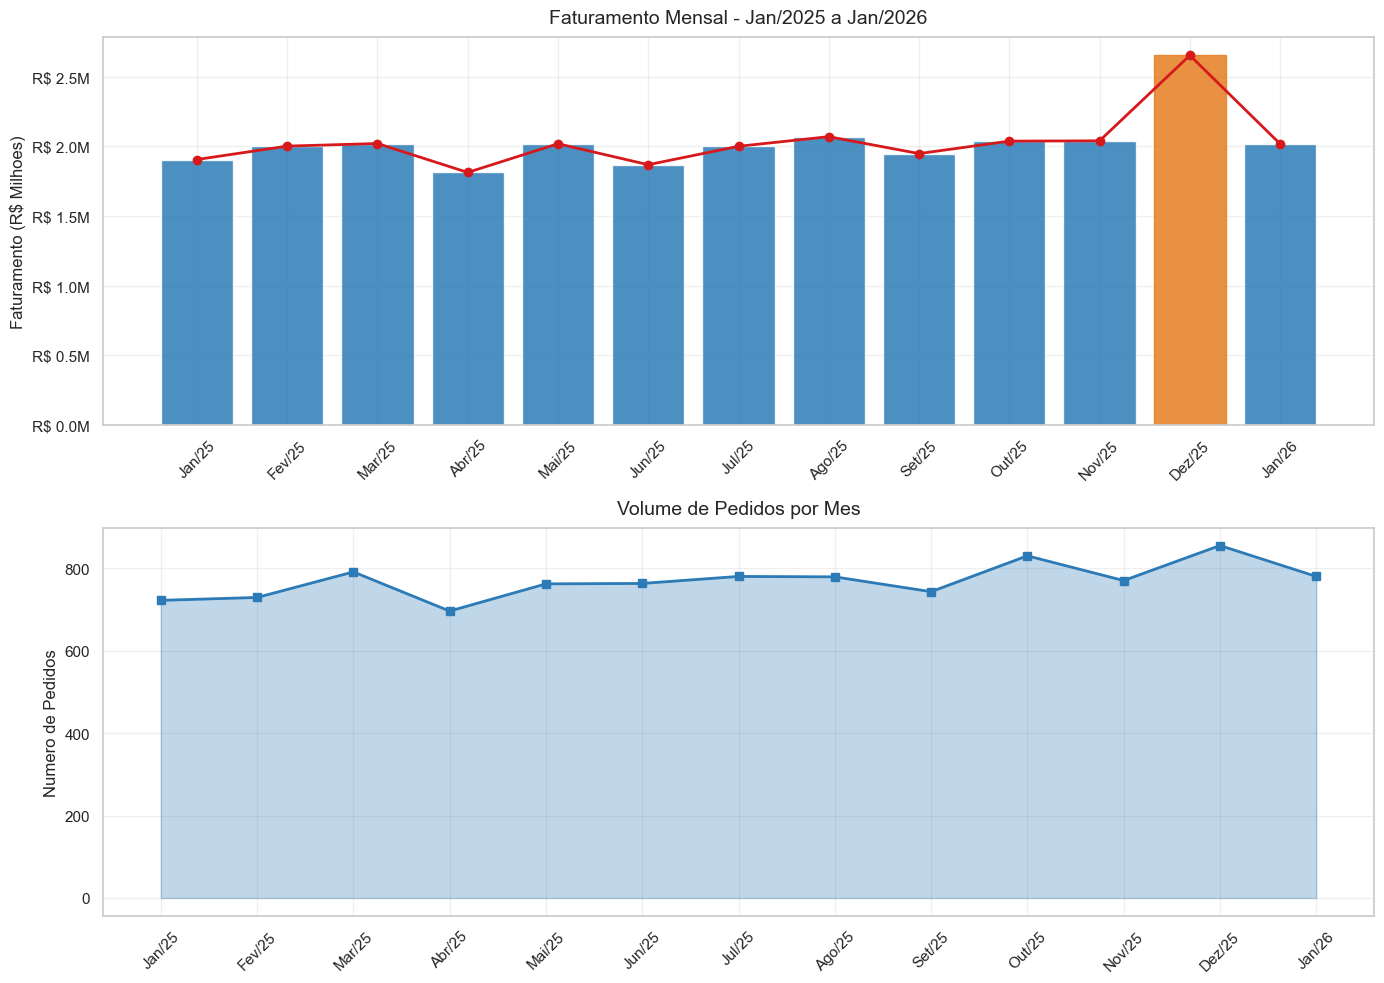

Insight: O volume de vendas se concentra nos meses de novembro e dezembro, tipico do setor varejista (Black Friday e Natal).


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Faturamento mensal
ax1 = axes[0]
bars = ax1.bar(vendas_mensais['label'], vendas_mensais['faturamento'] / 1e6,
               color=PALETA_PRINCIPAL, alpha=0.85, edgecolor='white')
ax1.plot(vendas_mensais['label'], vendas_mensais['faturamento'] / 1e6,
         color=PALETA_SECUNDARIA, marker='o', linewidth=2, markersize=6, zorder=5)

# Destacar o mes de maior faturamento
idx_max = vendas_mensais['faturamento'].idxmax()
bars[vendas_mensais.index.get_loc(idx_max)].set_color('#e67e22')

ax1.set_title('Faturamento Mensal - Jan/2025 a Jan/2026', fontsize=14, pad=10)
ax1.set_ylabel('Faturamento (R$ Milhoes)')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('R$ %.1fM'))

# Numero de pedidos mensais
ax2 = axes[1]
ax2.fill_between(range(len(vendas_mensais)), vendas_mensais['pedidos'],
                 alpha=0.3, color=PALETA_PRINCIPAL)
ax2.plot(range(len(vendas_mensais)), vendas_mensais['pedidos'],
         color=PALETA_PRINCIPAL, marker='s', linewidth=2, markersize=6)
ax2.set_xticks(range(len(vendas_mensais)))
ax2.set_xticklabels(vendas_mensais['label'], rotation=45)
ax2.set_title('Volume de Pedidos por Mes', fontsize=14, pad=10)
ax2.set_ylabel('Numero de Pedidos')

plt.tight_layout()
plt.savefig('grafico_faturamento_mensal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: O volume de vendas se concentra nos meses de novembro e dezembro, tipico do setor varejista (Black Friday e Natal).')

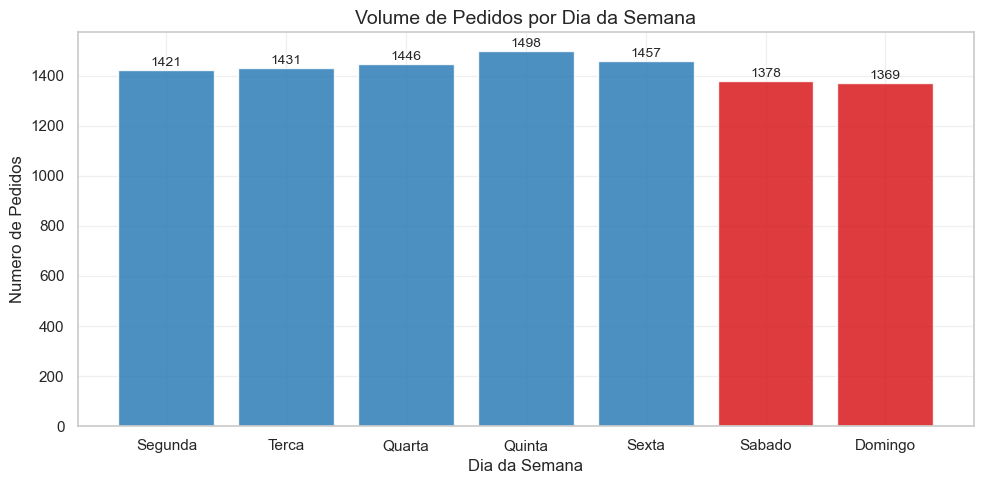

Insight: O comportamento de compra e relativamente distribuido ao longo da semana, com leve queda nas segundas-feiras.


In [9]:
# Analise por dia da semana
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_pt = {'Monday': 'Segunda', 'Tuesday': 'Terca', 'Wednesday': 'Quarta',
           'Thursday': 'Quinta', 'Friday': 'Sexta', 'Saturday': 'Sabado', 'Sunday': 'Domingo'}

vendas_dia = df.groupby('dia_semana').agg(
    faturamento=('valor_total', 'sum'),
    pedidos=('id_venda', 'count')
).reindex(ordem_dias).reset_index()
vendas_dia['dia_pt'] = vendas_dia['dia_semana'].map(dias_pt)

fig, ax = plt.subplots(figsize=(10, 5))
cores = [PALETA_SECUNDARIA if d in ['Saturday', 'Sunday'] else PALETA_PRINCIPAL for d in vendas_dia['dia_semana']]
ax.bar(vendas_dia['dia_pt'], vendas_dia['pedidos'], color=cores, alpha=0.85, edgecolor='white')
ax.set_title('Volume de Pedidos por Dia da Semana', fontsize=14)
ax.set_ylabel('Numero de Pedidos')
ax.set_xlabel('Dia da Semana')
for i, v in enumerate(vendas_dia['pedidos']):
    ax.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('grafico_dia_semana.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: O comportamento de compra e relativamente distribuido ao longo da semana, com leve queda nas segundas-feiras.')

## 6. Analise por Categoria de Produto

In [10]:
cat_analise = df.groupby('categoria').agg(
    faturamento=('valor_total', 'sum'),
    margem=('margem_bruta', 'sum'),
    pedidos=('id_venda', 'count'),
    ticket_medio=('valor_total', 'mean'),
    preco_medio=('preco_unitario', 'mean')
).reset_index()

cat_analise['pct_faturamento'] = (cat_analise['faturamento'] / cat_analise['faturamento'].sum() * 100).round(1)
cat_analise['pct_margem'] = (cat_analise['margem'] / cat_analise['faturamento'] * 100).round(1)
cat_analise = cat_analise.sort_values('faturamento', ascending=False)

print('Analise por Categoria:')
print(cat_analise[['categoria', 'faturamento', 'pct_faturamento', 'pct_margem', 'pedidos', 'ticket_medio']].to_string(index=False))

Analise por Categoria:
      categoria  faturamento  pct_faturamento  pct_margem  pedidos  ticket_medio
      Notebooks   5111058.93             19.4        42.8     1015   5035.526039
    Televisores   4789340.01             18.1        42.4      984   4867.215457
 Refrigeradores   3455512.74             13.1        42.2     1003   3445.177208
      Lavadoras   2862429.32             10.8        41.8      992   2885.513427
    Smartphones   2827561.61             10.7        42.7     1004   2816.296424
Ar Condicionado   2615531.12              9.9        42.8      968   2701.994959
        Tablets   1775040.39              6.7        42.6     1046   1696.979340
         Fogoes   1325841.57              5.0        42.4     1019   1301.120285
    Aspiradores    999810.24              3.8        42.2     1005    994.836060
    Micro-ondas    644064.44              2.4        42.6      964    668.116639


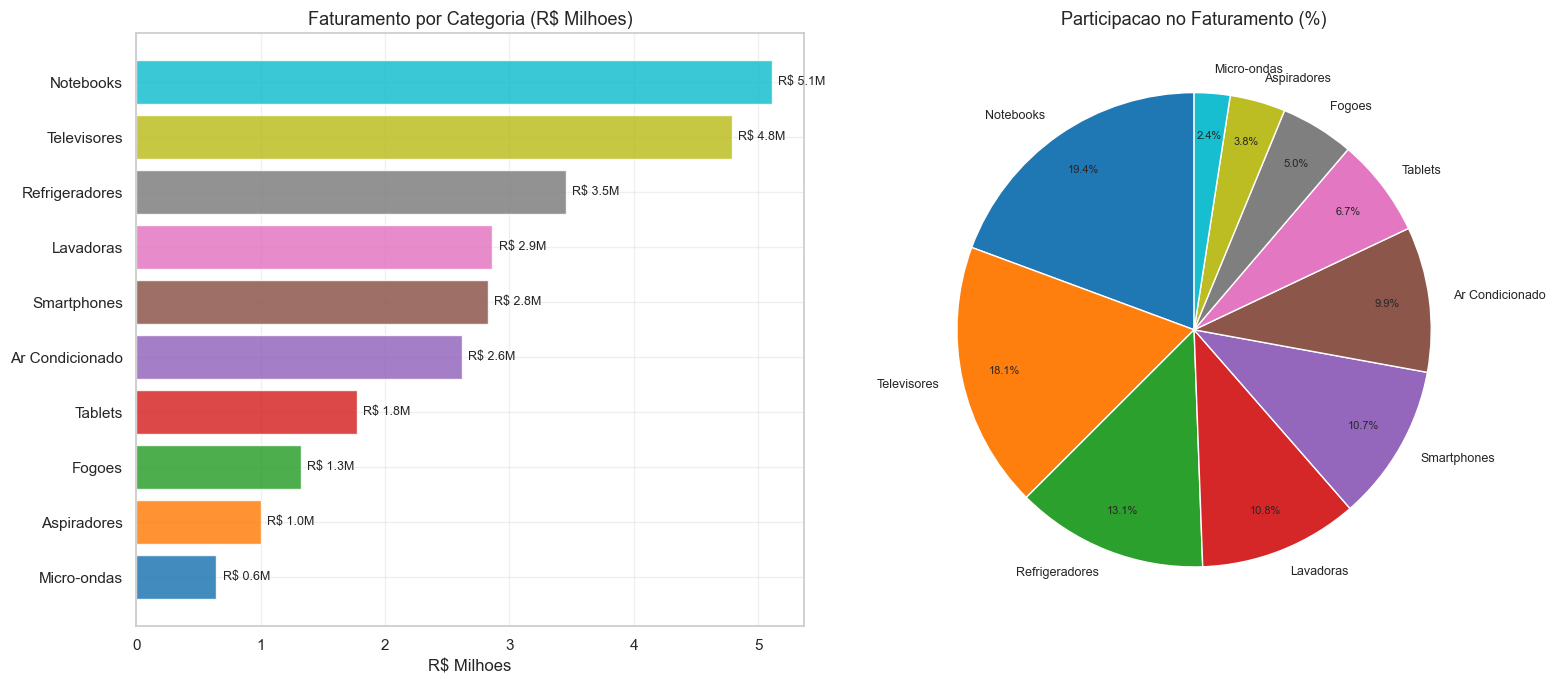

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Faturamento por categoria
cat_sorted = cat_analise.sort_values('faturamento')
cores_cat = sns.color_palette('tab10', len(cat_sorted))
axes[0].barh(cat_sorted['categoria'], cat_sorted['faturamento'] / 1e6,
             color=cores_cat, edgecolor='white', alpha=0.85)
axes[0].set_title('Faturamento por Categoria (R$ Milhoes)', fontsize=13)
axes[0].set_xlabel('R$ Milhoes')
for i, v in enumerate(cat_sorted['faturamento'] / 1e6):
    axes[0].text(v + 0.05, i, f'R$ {v:.1f}M', va='center', fontsize=9)

# Participacao percentual - pizza
wedges, texts, autotexts = axes[1].pie(
    cat_analise['faturamento'],
    labels=cat_analise['categoria'],
    autopct='%1.1f%%',
    colors=sns.color_palette('tab10', len(cat_analise)),
    startangle=90,
    pctdistance=0.82
)
for text in texts:
    text.set_fontsize(9)
for autotext in autotexts:
    autotext.set_fontsize(8)
axes[1].set_title('Participacao no Faturamento (%)', fontsize=13)

plt.tight_layout()
plt.savefig('grafico_categorias.png', dpi=150, bbox_inches='tight')
plt.show()

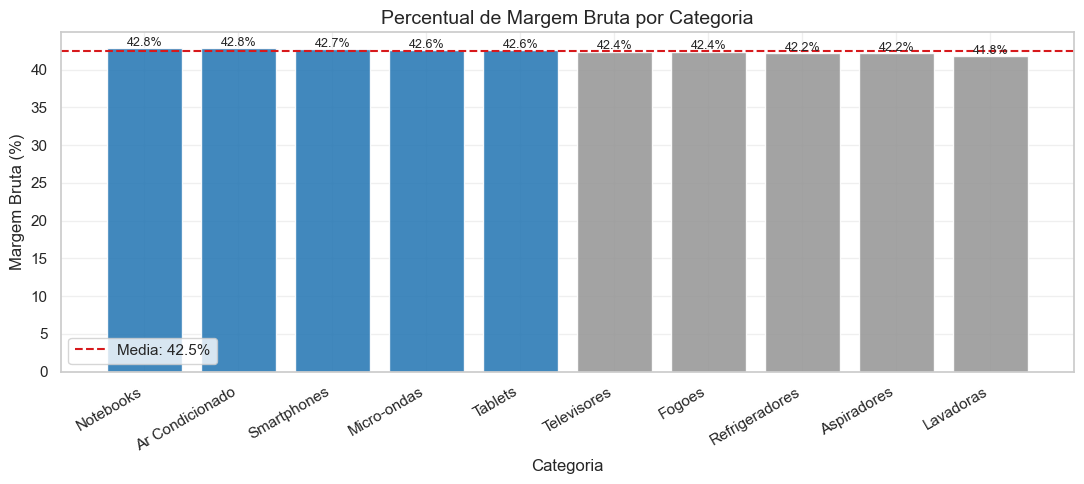

Insight: Categorias como Notebooks e Smartphones tendem a ter margem menor por conta da competitividade de preco, enquanto Ar Condicionado e Refrigeradores costumam sustentar margens mais elevadas.


In [12]:
# Margem por categoria
cat_margem = cat_analise.sort_values('pct_margem', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
cores_margem = [PALETA_PRINCIPAL if v > cat_margem['pct_margem'].mean() else '#999999'
               for v in cat_margem['pct_margem']]
bars = ax.bar(cat_margem['categoria'], cat_margem['pct_margem'],
              color=cores_margem, edgecolor='white', alpha=0.9)
ax.axhline(cat_margem['pct_margem'].mean(), color=PALETA_SECUNDARIA,
           linestyle='--', linewidth=1.5, label=f'Media: {cat_margem["pct_margem"].mean():.1f}%')
ax.set_title('Percentual de Margem Bruta por Categoria', fontsize=14)
ax.set_ylabel('Margem Bruta (%)')
ax.set_xlabel('Categoria')
ax.legend()
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(cat_margem['pct_margem']):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('grafico_margem_categorias.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Categorias como Notebooks e Smartphones tendem a ter margem menor por conta da competitividade de preco, enquanto Ar Condicionado e Refrigeradores costumam sustentar margens mais elevadas.')

## 7. Analise por Marca

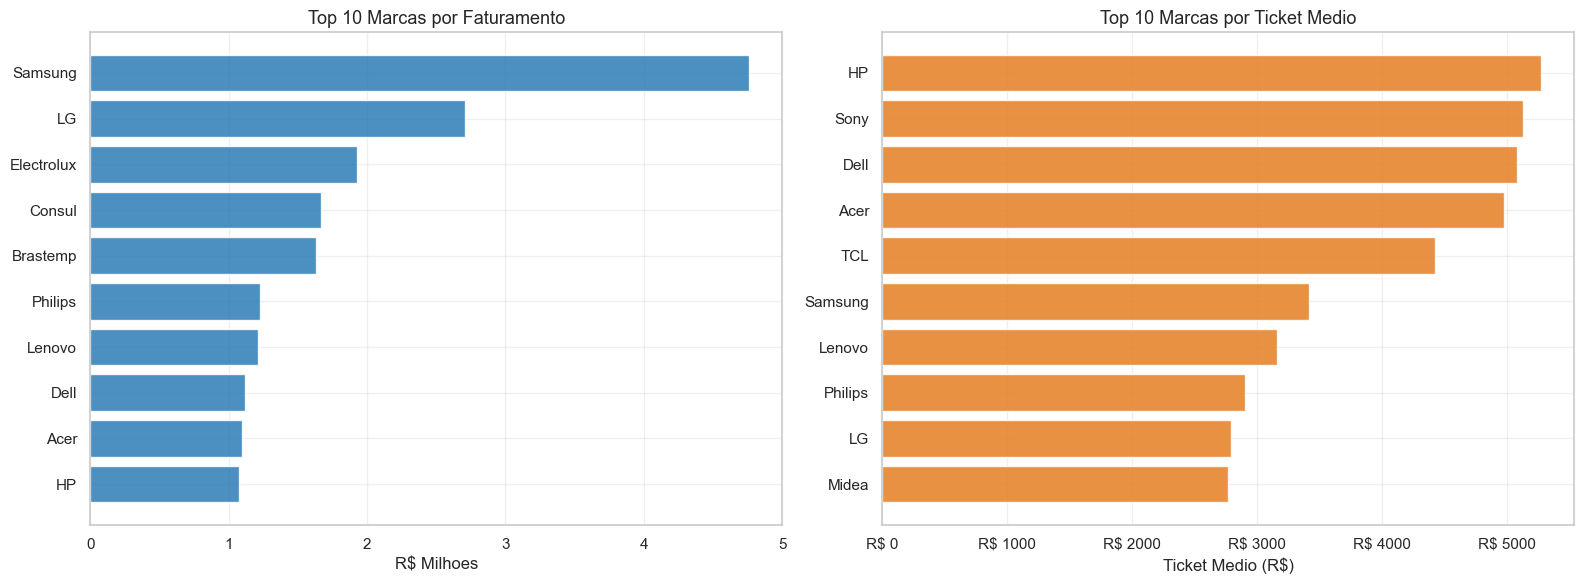

In [13]:
top_marcas = df.groupby('marca').agg(
    faturamento=('valor_total', 'sum'),
    pedidos=('id_venda', 'count'),
    ticket_medio=('valor_total', 'mean')
).sort_values('faturamento', ascending=False).head(15).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top marcas por faturamento
top10 = top_marcas.head(10).sort_values('faturamento')
axes[0].barh(top10['marca'], top10['faturamento'] / 1e6,
             color=PALETA_PRINCIPAL, alpha=0.85)
axes[0].set_title('Top 10 Marcas por Faturamento', fontsize=13)
axes[0].set_xlabel('R$ Milhoes')

# Ticket medio por marca
top10_ticket = top_marcas.sort_values('ticket_medio', ascending=False).head(10).sort_values('ticket_medio')
axes[1].barh(top10_ticket['marca'], top10_ticket['ticket_medio'],
             color='#e67e22', alpha=0.85)
axes[1].set_title('Top 10 Marcas por Ticket Medio', fontsize=13)
axes[1].set_xlabel('Ticket Medio (R$)')
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('R$ %.0f'))

plt.tight_layout()
plt.savefig('grafico_marcas.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Analise por Canal de Venda

In [14]:
canal_analise = df.groupby('canal_venda').agg(
    faturamento=('valor_total', 'sum'),
    pedidos=('id_venda', 'count'),
    ticket_medio=('valor_total', 'mean'),
    margem=('margem_bruta', 'sum'),
    avaliacao=('avaliacao_cliente', 'mean')
).reset_index()
canal_analise['pct'] = (canal_analise['pedidos'] / canal_analise['pedidos'].sum() * 100).round(1)

print('Performance por Canal de Venda:')
print(canal_analise[['canal_venda', 'pedidos', 'pct', 'faturamento', 'ticket_medio', 'avaliacao']].to_string(index=False))

Performance por Canal de Venda:
canal_venda  pedidos  pct  faturamento  ticket_medio  avaliacao
 App Mobile     1468 14.7   3833530.26   2611.396635   3.983622
 E-commerce     3934 39.3  10362803.37   2634.164558   4.012792
Loja Fisica     3582 35.8   9465226.99   2642.441929   4.044622
 Televendas     1016 10.2   2744629.75   2701.407234   4.034335


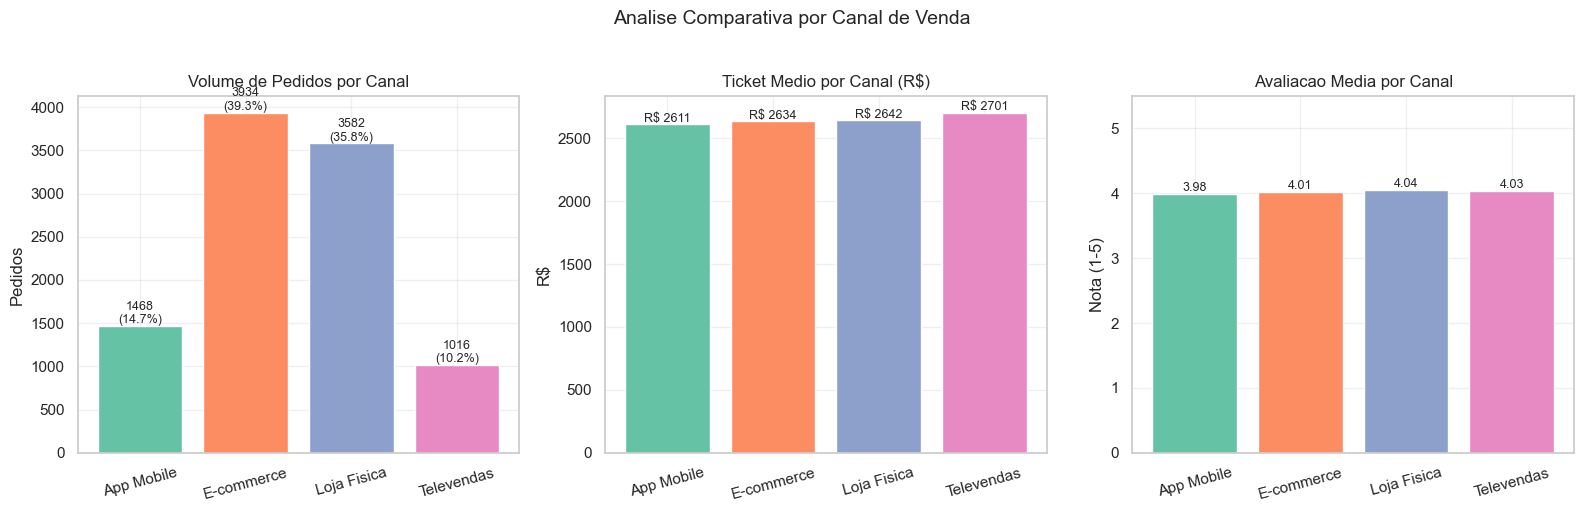

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cores_canal = sns.color_palette('Set2', len(canal_analise))

# Volume de pedidos
axes[0].bar(canal_analise['canal_venda'], canal_analise['pedidos'], color=cores_canal, edgecolor='white')
axes[0].set_title('Volume de Pedidos por Canal')
axes[0].set_ylabel('Pedidos')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(canal_analise['pedidos']):
    axes[0].text(i, v + 30, f'{v}\n({canal_analise["pct"].iloc[i]}%)', ha='center', fontsize=9)

# Ticket medio por canal
axes[1].bar(canal_analise['canal_venda'], canal_analise['ticket_medio'], color=cores_canal, edgecolor='white')
axes[1].set_title('Ticket Medio por Canal (R$)')
axes[1].set_ylabel('R$')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(canal_analise['ticket_medio']):
    axes[1].text(i, v + 20, f'R$ {v:.0f}', ha='center', fontsize=9)

# Avaliacao media por canal
axes[2].bar(canal_analise['canal_venda'], canal_analise['avaliacao'], color=cores_canal, edgecolor='white')
axes[2].set_title('Avaliacao Media por Canal')
axes[2].set_ylabel('Nota (1-5)')
axes[2].set_ylim(0, 5.5)
axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate(canal_analise['avaliacao']):
    axes[2].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('Analise Comparativa por Canal de Venda', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('grafico_canais.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Analise Geografica

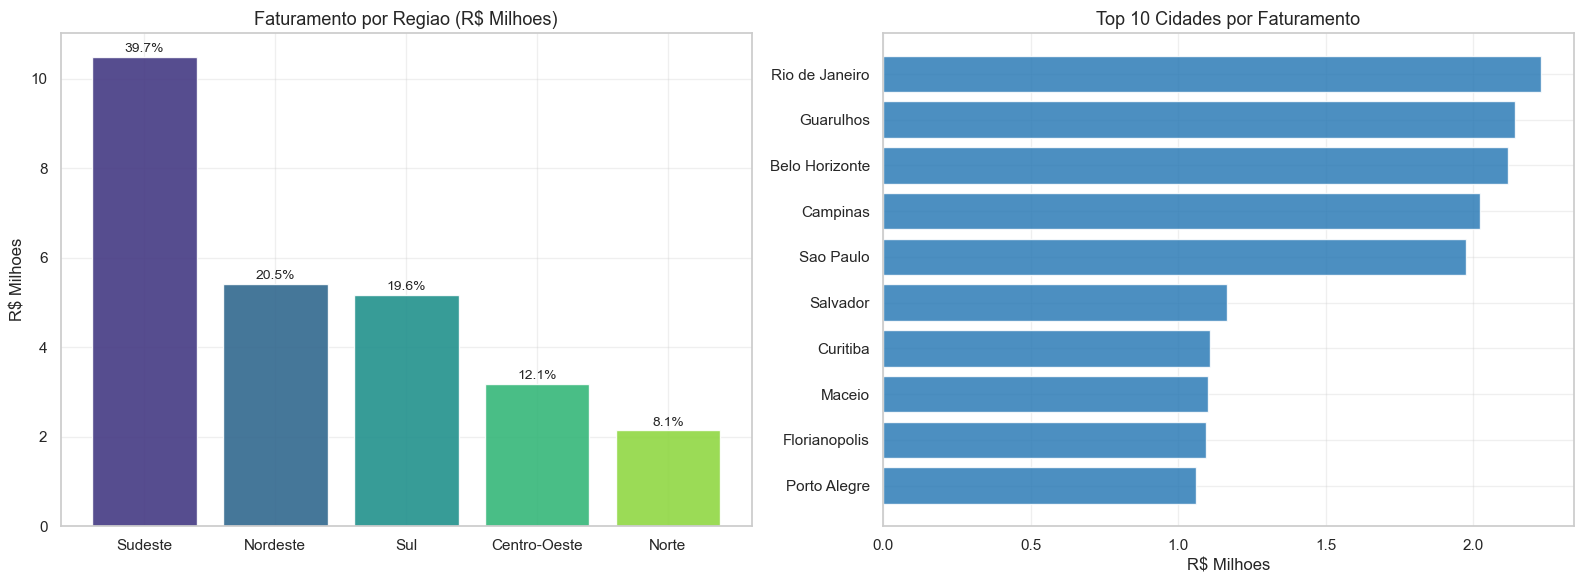

Insight: O Sudeste domina o faturamento, o que e esperado dado seu peso demografico. Vale monitorar o crescimento do Nordeste e Sul.


In [16]:
regiao_analise = df.groupby('regiao').agg(
    faturamento=('valor_total', 'sum'),
    pedidos=('id_venda', 'count'),
    ticket_medio=('valor_total', 'mean')
).reset_index().sort_values('faturamento', ascending=False)
regiao_analise['pct'] = (regiao_analise['faturamento'] / regiao_analise['faturamento'].sum() * 100).round(1)

# Top 10 cidades
top_cidades = df.groupby('cidade').agg(
    faturamento=('valor_total', 'sum'),
    pedidos=('id_venda', 'count')
).sort_values('faturamento', ascending=False).head(10).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cores_regiao = sns.color_palette('viridis', len(regiao_analise))
axes[0].bar(regiao_analise['regiao'], regiao_analise['faturamento'] / 1e6,
            color=cores_regiao, edgecolor='white', alpha=0.9)
axes[0].set_title('Faturamento por Regiao (R$ Milhoes)', fontsize=13)
axes[0].set_ylabel('R$ Milhoes')
for i, row in regiao_analise.reset_index().iterrows():
    axes[0].text(i, row['faturamento'] / 1e6 + 0.1, f'{row["pct"]}%', ha='center', fontsize=10)

top_cidades_plot = top_cidades.sort_values('faturamento')
axes[1].barh(top_cidades_plot['cidade'], top_cidades_plot['faturamento'] / 1e6,
             color=PALETA_PRINCIPAL, alpha=0.85)
axes[1].set_title('Top 10 Cidades por Faturamento', fontsize=13)
axes[1].set_xlabel('R$ Milhoes')

plt.tight_layout()
plt.savefig('grafico_geografico.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: O Sudeste domina o faturamento, o que e esperado dado seu peso demografico. Vale monitorar o crescimento do Nordeste e Sul.')

## 10. Analise de Formas de Pagamento

In [17]:
pagamento_analise = df.groupby('forma_pagamento').agg(
    pedidos=('id_venda', 'count'),
    faturamento=('valor_total', 'sum'),
    ticket_medio=('valor_total', 'mean'),
    desconto_medio=('desconto_percentual', 'mean')
).reset_index().sort_values('pedidos', ascending=False)
pagamento_analise['pct'] = (pagamento_analise['pedidos'] / pagamento_analise['pedidos'].sum() * 100).round(1)

print('Analise por Forma de Pagamento:')
print(pagamento_analise.to_string(index=False))

Analise por Forma de Pagamento:
forma_pagamento  pedidos  faturamento  ticket_medio  desconto_medio  pct
 Cartao Credito     3477   9236236.41   2656.380906        6.271211 34.8
            PIX     2518   6575464.60   2611.383876        6.393963 25.2
  Cartao Debito     1521   3989851.40   2623.176463        6.433268 15.2
  Financiamento     1492   4015673.52   2691.470188        6.508043 14.9
         Boleto      992   2588964.44   2609.843185        6.658266  9.9


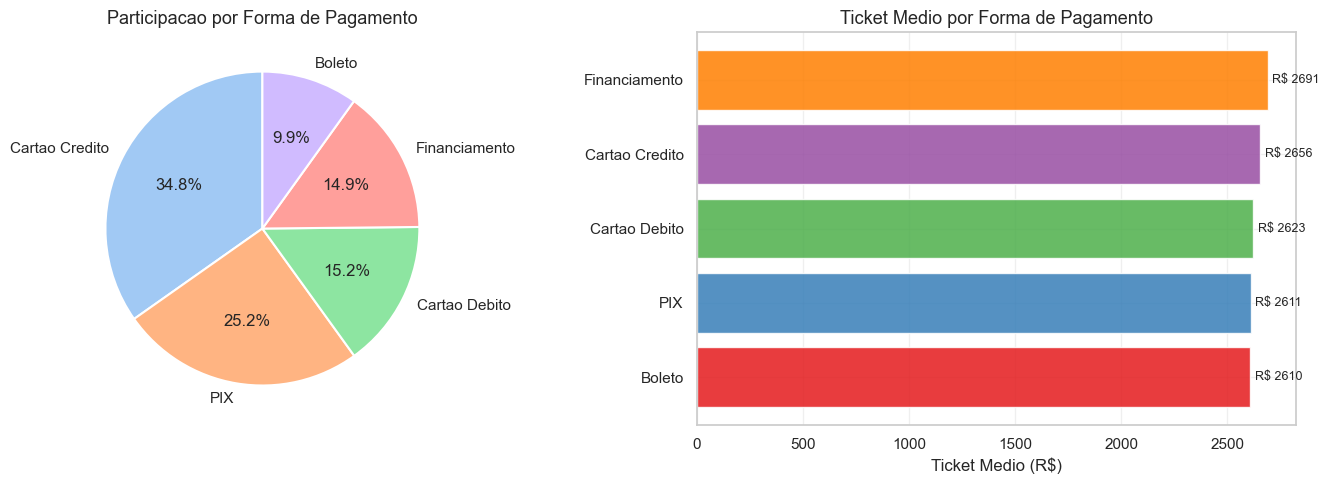

Insight: O PIX ganhou espaco expressivo como forma de pagamento, enquanto o Financiamento apresenta o maior ticket medio, indicando uso em produtos de alto valor.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores_pag = sns.color_palette('pastel', len(pagamento_analise))

wedges, texts, autotexts = axes[0].pie(
    pagamento_analise['pedidos'],
    labels=pagamento_analise['forma_pagamento'],
    autopct='%1.1f%%',
    colors=cores_pag,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[0].set_title('Participacao por Forma de Pagamento', fontsize=13)

pag_ticket = pagamento_analise.sort_values('ticket_medio')
axes[1].barh(pag_ticket['forma_pagamento'], pag_ticket['ticket_medio'],
             color=sns.color_palette('Set1', len(pag_ticket)), alpha=0.85)
axes[1].set_title('Ticket Medio por Forma de Pagamento', fontsize=13)
axes[1].set_xlabel('Ticket Medio (R$)')
for i, v in enumerate(pag_ticket['ticket_medio']):
    axes[1].text(v + 20, i, f'R$ {v:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('grafico_pagamentos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: O PIX ganhou espaco expressivo como forma de pagamento, enquanto o Financiamento apresenta o maior ticket medio, indicando uso em produtos de alto valor.')

## 11. Analise de Descontos

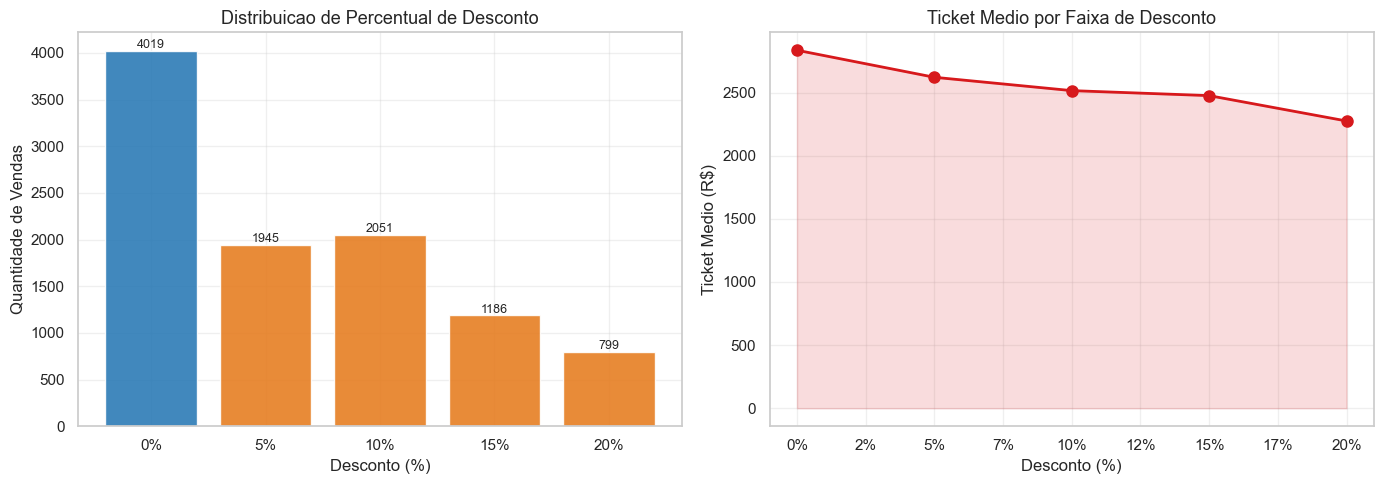

Total concedido em descontos: R$ 1,814,164.53 (6.9% do faturamento bruto)
Media de desconto por venda: R$ 181.42


In [19]:
# Distribuicao dos descontos
desc_dist = df['desconto_percentual'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuicao simples
cores_desc = [PALETA_PRINCIPAL if v == 0 else '#e67e22' for v in desc_dist.index]
axes[0].bar(desc_dist.index.astype(str) + '%', desc_dist.values, color=cores_desc, edgecolor='white', alpha=0.9)
axes[0].set_title('Distribuicao de Percentual de Desconto', fontsize=13)
axes[0].set_xlabel('Desconto (%)')
axes[0].set_ylabel('Quantidade de Vendas')
for i, v in enumerate(desc_dist.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=9)

# Ticket medio por faixa de desconto
ticket_desc = df.groupby('desconto_percentual')['valor_total'].mean().reset_index()
axes[1].plot(ticket_desc['desconto_percentual'], ticket_desc['valor_total'],
             marker='o', color=PALETA_SECUNDARIA, linewidth=2, markersize=8)
axes[1].fill_between(ticket_desc['desconto_percentual'], ticket_desc['valor_total'],
                     alpha=0.15, color=PALETA_SECUNDARIA)
axes[1].set_title('Ticket Medio por Faixa de Desconto', fontsize=13)
axes[1].set_xlabel('Desconto (%)')
axes[1].set_ylabel('Ticket Medio (R$)')
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('%d%%'))

plt.tight_layout()
plt.savefig('grafico_descontos.png', dpi=150, bbox_inches='tight')
plt.show()

total_desc = df['valor_desconto'].sum()
pct_desc_fat = total_desc / df['valor_total'].sum() * 100
print(f'Total concedido em descontos: R$ {total_desc:,.2f} ({pct_desc_fat:.1f}% do faturamento bruto)')
print(f'Media de desconto por venda: R$ {df["valor_desconto"].mean():.2f}')

## 12. Analise de Avaliacoes e Devolucoes

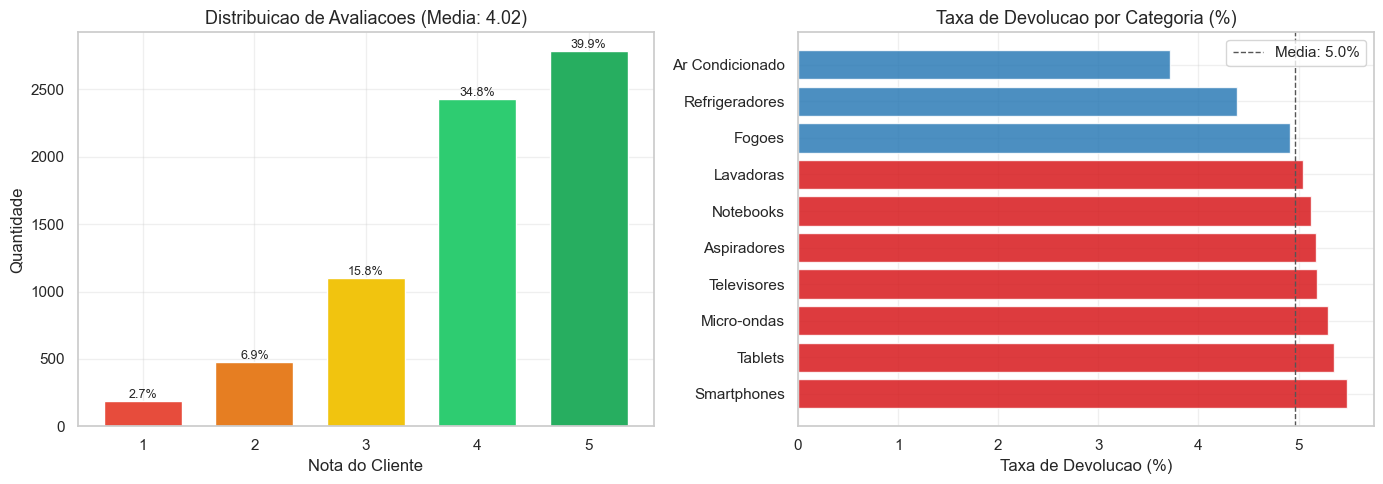

In [20]:
# Avaliacoes
avaliacoes = df['avaliacao_cliente'].dropna()
avaliacao_dist = avaliacoes.value_counts().sort_index()

# Devolucoes por categoria
dev_cat = df.groupby('categoria')['devolvido'].agg(['sum', 'count', 'mean']).reset_index()
dev_cat.columns = ['categoria', 'total_devolvido', 'total_vendas', 'taxa_devolucao']
dev_cat['taxa_devolucao_pct'] = (dev_cat['taxa_devolucao'] * 100).round(2)
dev_cat = dev_cat.sort_values('taxa_devolucao_pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuicao de avaliacoes
cores_av = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
axes[0].bar(avaliacao_dist.index.astype(int), avaliacao_dist.values,
            color=cores_av, edgecolor='white', width=0.7)
axes[0].set_title(f'Distribuicao de Avaliacoes (Media: {avaliacoes.mean():.2f})', fontsize=13)
axes[0].set_xlabel('Nota do Cliente')
axes[0].set_ylabel('Quantidade')
axes[0].set_xticks([1, 2, 3, 4, 5])
for i, (nota, qtd) in enumerate(zip(avaliacao_dist.index, avaliacao_dist.values)):
    pct = qtd / avaliacao_dist.sum() * 100
    axes[0].text(nota, qtd + 20, f'{pct:.1f}%', ha='center', fontsize=9)

# Taxa de devolucao por categoria
cores_dev = [PALETA_SECUNDARIA if v > dev_cat['taxa_devolucao_pct'].mean() else PALETA_PRINCIPAL
             for v in dev_cat['taxa_devolucao_pct']]
axes[1].barh(dev_cat['categoria'], dev_cat['taxa_devolucao_pct'],
             color=cores_dev, alpha=0.85)
axes[1].axvline(dev_cat['taxa_devolucao_pct'].mean(), color='#555', linestyle='--', linewidth=1,
                label=f'Media: {dev_cat["taxa_devolucao_pct"].mean():.1f}%')
axes[1].set_title('Taxa de Devolucao por Categoria (%)', fontsize=13)
axes[1].set_xlabel('Taxa de Devolucao (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('grafico_avaliacoes_devolucoes.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Analise de Correlacao e Distribuicao de Valores

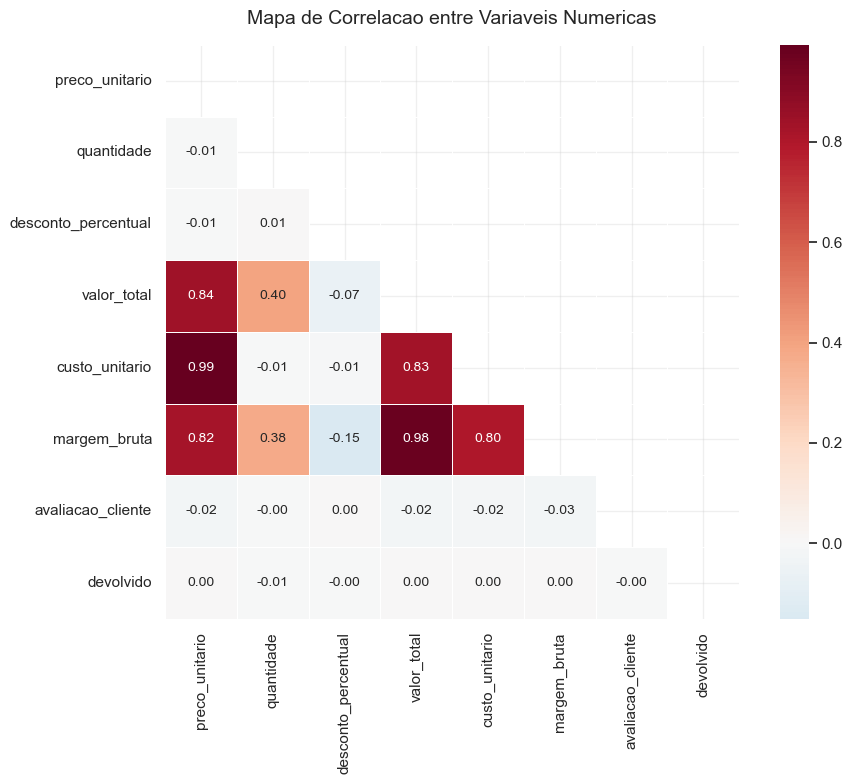

Insight: Existe forte correlacao entre preco_unitario e valor_total, o que e esperado. A correlacao entre desconto e avaliacao e praticamente nula, indicando que preco nao e o principal fator de satisfacao.


In [21]:
# Correlacao entre variaveis numericas
cols_num = ['preco_unitario', 'quantidade', 'desconto_percentual', 'valor_total',
            'custo_unitario', 'margem_bruta', 'avaliacao_cliente', 'devolvido']

corr_matrix = df[cols_num].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            mask=mask, ax=ax, annot_kws={'size': 10})
ax.set_title('Mapa de Correlacao entre Variaveis Numericas', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('grafico_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Existe forte correlacao entre preco_unitario e valor_total, o que e esperado. A correlacao entre desconto e avaliacao e praticamente nula, indicando que preco nao e o principal fator de satisfacao.')

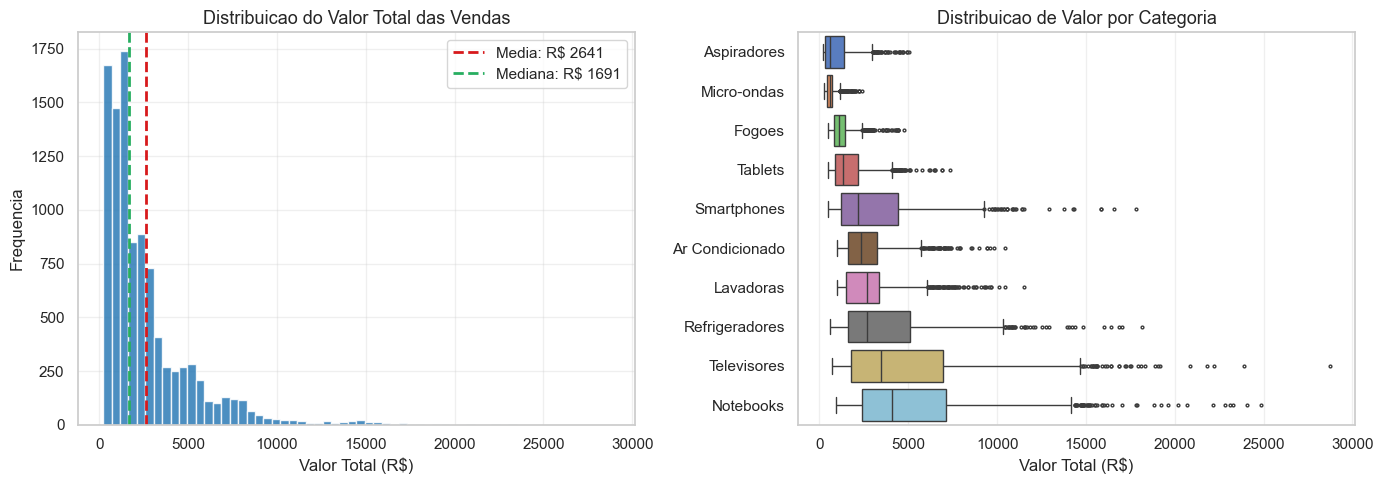

In [22]:
# Distribuicao dos valores de venda
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma do valor total
axes[0].hist(df['valor_total'], bins=60, color=PALETA_PRINCIPAL, edgecolor='white', alpha=0.85)
axes[0].axvline(df['valor_total'].mean(), color=PALETA_SECUNDARIA, linestyle='--',
                linewidth=2, label=f'Media: R$ {df["valor_total"].mean():.0f}')
axes[0].axvline(df['valor_total'].median(), color='#27ae60', linestyle='--',
                linewidth=2, label=f'Mediana: R$ {df["valor_total"].median():.0f}')
axes[0].set_title('Distribuicao do Valor Total das Vendas', fontsize=13)
axes[0].set_xlabel('Valor Total (R$)')
axes[0].set_ylabel('Frequencia')
axes[0].legend()

# Boxplot de valor total por categoria
cat_order = df.groupby('categoria')['valor_total'].median().sort_values().index.tolist()
df_box = df[['categoria', 'valor_total']].copy()
df_box['cat_label'] = pd.Categorical(df_box['categoria'], categories=cat_order, ordered=True)
df_box_sorted = df_box.sort_values('cat_label')

sns.boxplot(data=df_box_sorted, x='valor_total', y='cat_label',
            ax=axes[1], palette='muted', fliersize=2)
axes[1].set_title('Distribuicao de Valor por Categoria', fontsize=13)
axes[1].set_xlabel('Valor Total (R$)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('grafico_distribuicao_valores.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Analise de Sazonalidade por Categoria

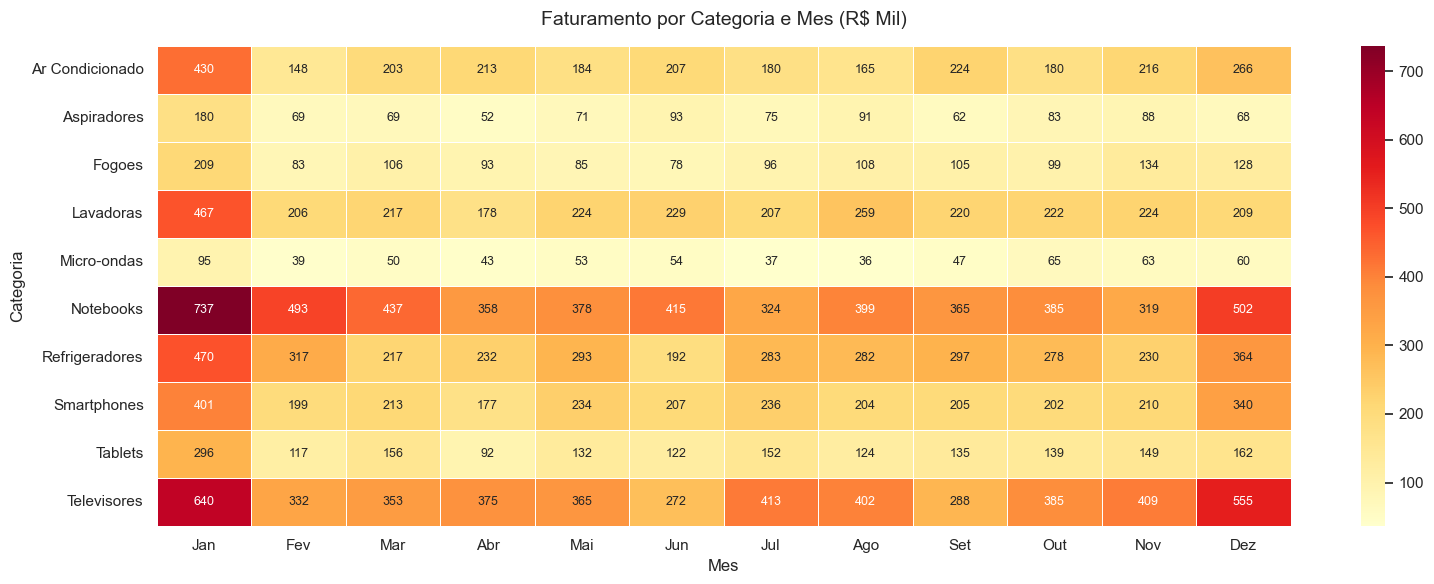

Insight: O heatmap revela que Televisores e Smartphones sao fortemente afetados pela sazonalidade de fim de ano. Ar Condicionado apresenta pico nos meses quentes.


In [23]:
# Heatmap de faturamento: categoria x mes
pivot_cat_mes = df.pivot_table(
    values='valor_total',
    index='categoria',
    columns='mes',
    aggfunc='sum'
) / 1000  # em R$ mil

pivot_cat_mes.columns = [meses_pt[c] for c in pivot_cat_mes.columns]

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot_cat_mes, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Faturamento por Categoria e Mes (R$ Mil)', fontsize=14, pad=15)
ax.set_xlabel('Mes')
ax.set_ylabel('Categoria')
plt.tight_layout()
plt.savefig('grafico_heatmap_sazonalidade.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: O heatmap revela que Televisores e Smartphones sao fortemente afetados pela sazonalidade de fim de ano. Ar Condicionado apresenta pico nos meses quentes.')

## 15. Top Produtos

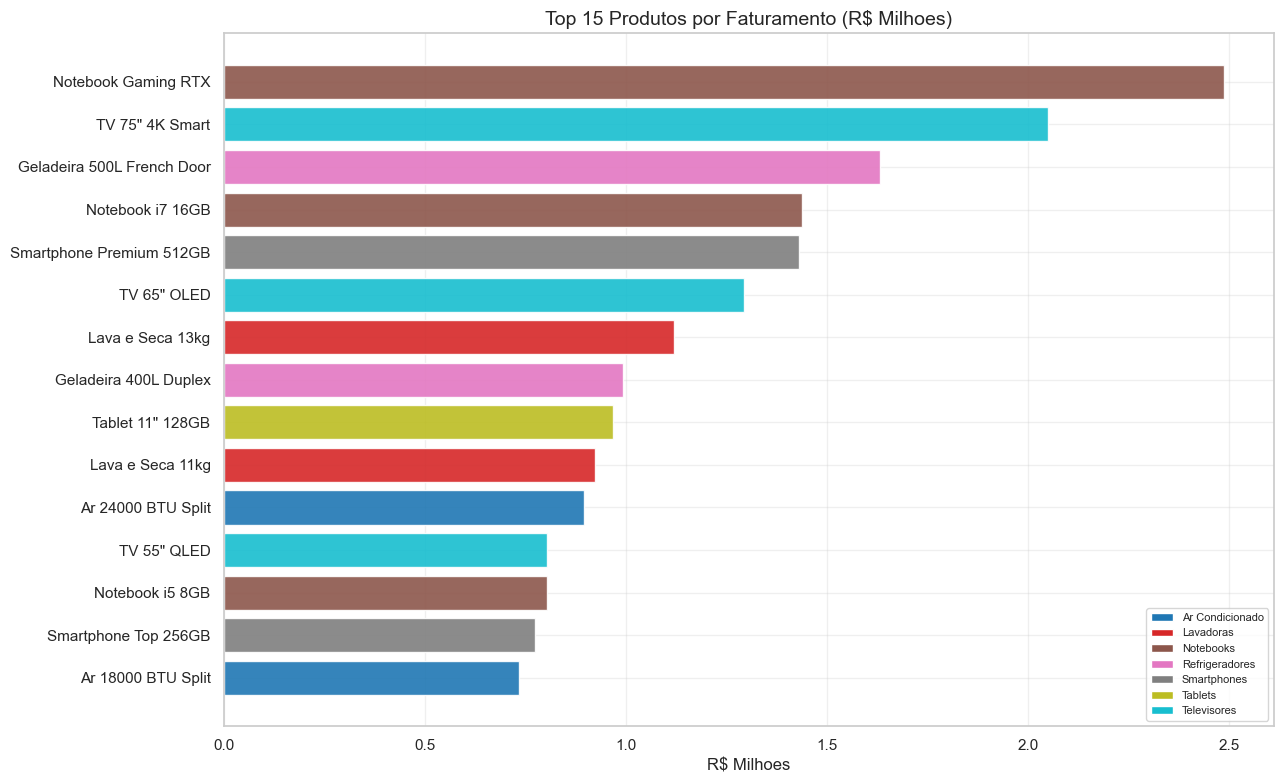

In [24]:
top_produtos = df.groupby(['produto', 'categoria']).agg(
    faturamento=('valor_total', 'sum'),
    pedidos=('id_venda', 'count'),
    ticket_medio=('valor_total', 'mean'),
    margem=('margem_bruta', 'sum')
).reset_index().sort_values('faturamento', ascending=False)

top15 = top_produtos.head(15)

fig, ax = plt.subplots(figsize=(13, 8))
top15_plot = top15.sort_values('faturamento')

# Cor por categoria
categorias_unicas = top15_plot['categoria'].unique()
cor_mapa = {cat: PALETA_CAT[i] for i, cat in enumerate(sorted(df['categoria'].unique()))}
cores_prod = [cor_mapa[cat] for cat in top15_plot['categoria']]

bars = ax.barh(top15_plot['produto'], top15_plot['faturamento'] / 1e6,
               color=cores_prod, edgecolor='white', alpha=0.9)
ax.set_title('Top 15 Produtos por Faturamento (R$ Milhoes)', fontsize=14)
ax.set_xlabel('R$ Milhoes')

# Legenda por categoria
from matplotlib.patches import Patch
legenda = [Patch(facecolor=cor_mapa[c], label=c) for c in sorted(df['categoria'].unique()) if c in top15['categoria'].values]
ax.legend(handles=legenda, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('grafico_top_produtos.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Estatisticas Descritivas Finais

In [25]:
# Estatisticas descritivas por categoria
resumo_final = df.groupby('categoria').agg(
    total_vendas=('id_venda', 'count'),
    faturamento_total=('valor_total', 'sum'),
    ticket_medio=('valor_total', 'mean'),
    ticket_mediano=('valor_total', 'median'),
    std_ticket=('valor_total', 'std'),
    margem_pct=('margem_bruta', lambda x: (x.sum() / df.loc[x.index, 'valor_total'].sum() * 100)),
    avaliacao_media=('avaliacao_cliente', 'mean'),
    taxa_devolucao=('devolvido', 'mean')
).round(2)

resumo_final['taxa_devolucao'] = (resumo_final['taxa_devolucao'] * 100).round(2)
resumo_final['faturamento_total'] = resumo_final['faturamento_total'].map('R$ {:,.0f}'.format)
resumo_final['ticket_medio'] = resumo_final['ticket_medio'].map('R$ {:,.0f}'.format)
resumo_final['ticket_mediano'] = resumo_final['ticket_mediano'].map('R$ {:,.0f}'.format)

print('Resumo Estatistico por Categoria:')
resumo_final

Resumo Estatistico por Categoria:


,total_vendas,faturamento_total,ticket_medio,ticket_mediano,std_ticket,margem_pct,avaliacao_media,taxa_devolucao
categoria,,,,,,,,
Ar Condicionado,968,"R$ 2,615,531","R$ 2,702","R$ 2,342",1515.26,42.80,4.04,4.0
Aspiradores,1005,"R$ 999,810",R$ 995,R$ 590,852.77,42.22,4.06,5.0
Fogoes,1019,"R$ 1,325,842","R$ 1,301","R$ 1,123",702.24,42.35,4.04,5.0
Lavadoras,992,"R$ 2,862,429","R$ 2,886","R$ 2,673",1737.11,41.84,3.94,5.0
Micro-ondas,964,"R$ 644,064",R$ 668,R$ 594,342.61,42.62,4.06,5.0
Notebooks,1015,"R$ 5,111,059","R$ 5,036","R$ 4,056",3811.28,42.79,4.05,5.0
Refrigeradores,1003,"R$ 3,455,513","R$ 3,445","R$ 2,687",2796.68,42.23,4.04,4.0
Smartphones,1004,"R$ 2,827,562","R$ 2,816","R$ 2,175",2451.95,42.65,4.00,5.0
Tablets,1046,"R$ 1,775,040","R$ 1,697","R$ 1,350",1074.32,42.56,4.00,5.0


## 17. Conclusoes e Insights Principais

Ao longo desta analise, foram examinados 10.000 registros de vendas da Loja Imaginaria de Eletro no periodo de janeiro de 2025 a janeiro de 2026. Os principais achados sao:

**Sazonalidade e Comportamento Temporal**

O faturamento da loja apresenta clara concentracao nos meses de novembro e dezembro, reflexo direto da Black Friday e das compras de Natal. Isso e um comportamento esperado para o setor, mas reforca a necessidade de planejamento de estoque e logistica com antecedencia para esses periodos.

**Categorias Estrategicas**

Televisores, Smartphones e Notebooks representam juntos a maior fatia do faturamento. Porem, ao olhar para a margem, Refrigeradores e Ar Condicionado se destacam por sustentar percentuais mais elevados. Isso indica uma oportunidade de rebalancear o mix de marketing para empurrar categorias que contribuem mais para a rentabilidade.

**Canais de Venda**

O E-commerce lidera em volume de pedidos, enquanto o canal Loja Fisica tende a registrar tickets medios maiores, provavelmente por conta do processo consultivo de venda presencial. O App Mobile vem crescendo e merece investimento continuo em experiencia do usuario.

**Formas de Pagamento**

O PIX consolidou-se como uma das formas de pagamento mais utilizadas. Vendas via Financiamento exibem os maiores tickets medios, confirmando que essa modalidade e essencial para converter produtos de alto valor.

**Satisfacao e Devolucoes**

A avaliacao media de 4+ pontos indica que a loja tem boa reputacao junto aos clientes. A taxa de devolucao em torno de 5% esta dentro da media do varejo de eletronicos, mas categorias especificas merecem atencao para investigacao das causas.

**Distribuicao Geografica**

O Sudeste concentra aproximadamente 40% das vendas. Existe espaco para crescimento nas regioes Norte e Centro-Oeste, que ainda apresentam participacao baixa mas com potencial de expansao digital.

---

*Analise realizada por Ivo dos Santos Viana Junior*  
*LinkedIn: https://www.linkedin.com/in/ivo-dos-santos-viana-j%C3%BAnior-1b3893198/*  
*GitHub: https://github.com/Juniorsantosviana/Analises-Ciencias-de-Dados*